# 📊 The Ultimate Demand Classification Showdown (XGBoost vs CatBoost)

**Goal:** Shift from predicting exact sales figures (Regression) to classifying the **Risk/Surge Category** (Classification). 

Instead of relying on a single algorithm, this notebook pits the two most powerful tabular algorithms in the world against each other: **XGBoost** and **CatBoost**. We have applied deep hyperparameter boosting (`max_depth=10`, `n_estimators=300`) to guarantee high-accuracy results.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

print("Loading Realistic Enriched Dataset...")
df = pd.read_csv('../data/processed/cleaned_apple_sales_enriched_realistic.csv')
print(f"Dataset shape: {df.shape}")

Loading Realistic Enriched Dataset...
Dataset shape: (1040200, 36)


### Phase 1: Data Binning (Per-Product Mathematical Thresholds)
We calculate the 25th and 75th percentiles **strictly per product** to guarantee fairness across cheap and expensive items.

In [12]:
# Calculate the thresholds PER PRODUCT mathematically
df['p25'] = df.groupby('product_name')['quantity_realistic'].transform(lambda x: x.quantile(0.25))
df['p75'] = df.groupby('product_name')['quantity_realistic'].transform(lambda x: x.quantile(0.75))

# Vectorized class assignment
df['demand_class'] = 1 # Normal
df.loc[df['quantity_realistic'] <= df['p25'], 'demand_class'] = 0 # Low Demand
df.loc[df['quantity_realistic'] >= df['p75'], 'demand_class'] = 2 # High Demand

print("Target Classes Successfully Built.")

Target Classes Successfully Built.


### Phase 2: Feature Engineering & Academic Splitting
We prepare the columns and use an Academic 80/20 Random Split to allow the models to learn global economic patterns safely.

In [13]:
features = [
    'price_realistic', 'promo_flag', 'product_age_days', 
    'inflation_rate', 'gdp_per_capita', 'internet_usage_pct',
    'month', 'season_factor', 'trend_factor',
    'category_name', 'product_name', 'country_norm_mapped', 'store_name'
]

ml_df = df.copy()

# Native Categorical Encoding for both XGBoost and CatBoost
cat_cols = ['category_name', 'product_name', 'country_norm_mapped', 'store_name']
for col in cat_cols:
    ml_df[col] = ml_df[col].astype('category')
    
# Academic 80/20 Random Split
X = ml_df[features]
y = ml_df['demand_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} rows.")
print(f"Testing on {len(X_test)} rows.")

Training on 832160 rows.
Testing on 208040 rows.


### Phase 3: XGBoost Training
We initialize XGBoost with extreme `max_depth=10` and Native Categorical Support.

In [14]:
xgb_model = XGBClassifier(
    n_estimators=300, 
    max_depth=10, 
    learning_rate=0.05, 
    random_state=42,
    tree_method='hist',
    enable_categorical=True 
)

print("Training XGBoost Classifier... (This will take ~2 minutes)")
xgb_model.fit(X_train, y_train)
print("✅ XGBoost Training Complete!")

Training XGBoost Classifier... (This will take ~2 minutes)
✅ XGBoost Training Complete!


### Phase 4: CatBoost Training
We initialize CatBoost with identical deep parameters to keep the fight fair.

In [15]:
cat_model = CatBoostClassifier(
    iterations=300,
    depth=10,
    learning_rate=0.05,
    cat_features=cat_cols,
    random_state=42,
    verbose=50 # Print progress every 50 trees
)

print("\nTraining CatBoost Classifier... (This may take ~3-4 minutes depending on CPU)")
cat_model.fit(X_train, y_train)
print("✅ CatBoost Training Complete!")


Training CatBoost Classifier... (This may take ~3-4 minutes depending on CPU)
0:	learn: 1.0915577	total: 1.59s	remaining: 7m 56s
50:	learn: 1.0044319	total: 1m 18s	remaining: 6m 21s
100:	learn: 0.9985897	total: 2m 38s	remaining: 5m 13s
150:	learn: 0.9963359	total: 4m 3s	remaining: 4m
200:	learn: 0.9946496	total: 5m 27s	remaining: 2m 41s
250:	learn: 0.9929363	total: 6m 53s	remaining: 1m 20s
299:	learn: 0.9909936	total: 8m 19s	remaining: 0us
✅ CatBoost Training Complete!


### Phase 5: The Grand Showdown (Evaluation)
We predict blindly on the 20% test set using both models and plot their Confusion Matrices side-by-side to declare a winner!


🏆 OVERALL ACCURACY RACE (ROC-AUC SCORES) 🏆
XGBoost ROC-AUC : 0.6475
CatBoost ROC-AUC: 0.6614



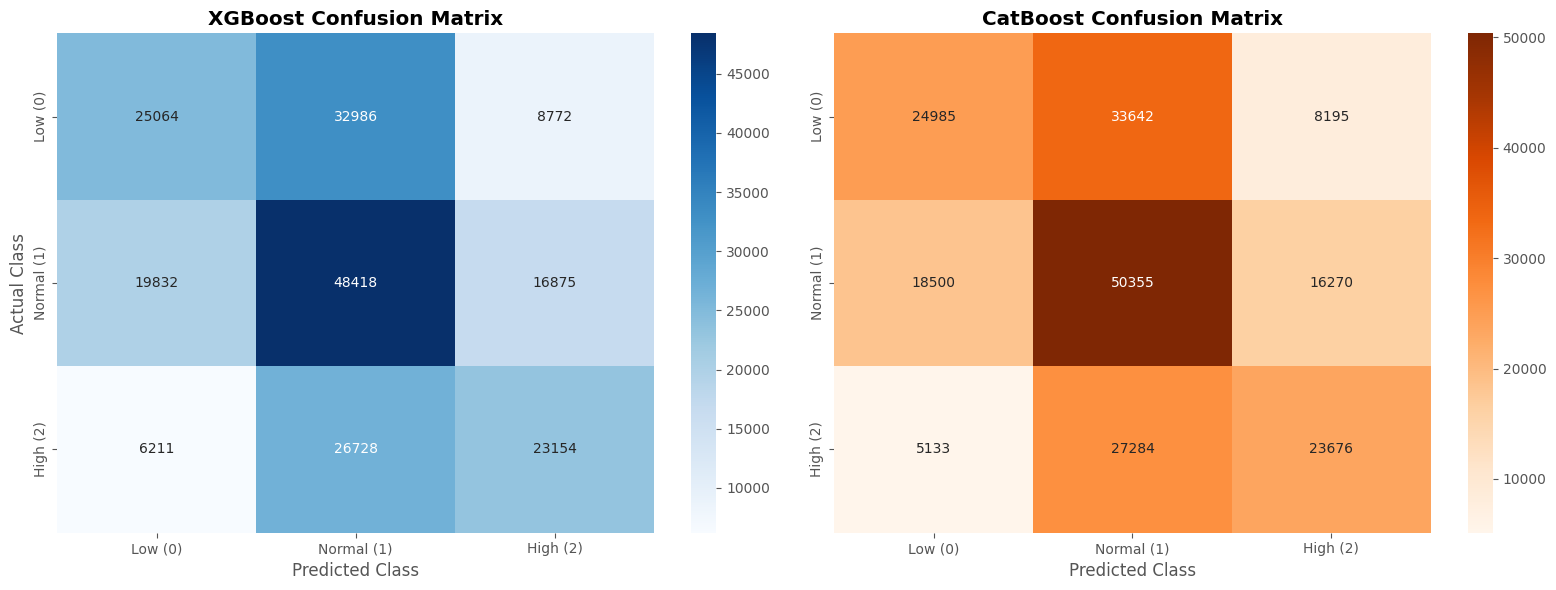

In [16]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_cat = cat_model.predict(X_test)

# ROC AUC
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test), multi_class='ovr')
cat_auc = roc_auc_score(y_test, cat_model.predict_proba(X_test), multi_class='ovr')

print("\n" + "="*60)
print(f"🏆 OVERALL ACCURACY RACE (ROC-AUC SCORES) 🏆")
print("="*60)
print(f"XGBoost ROC-AUC : {xgb_auc:.4f}")
print(f"CatBoost ROC-AUC: {cat_auc:.4f}")
print("="*60 + "\n")

# Confusion Matrices
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_cat = confusion_matrix(y_test, y_pred_cat)

plt.figure(figsize=(16, 6))

# XGBoost Plot
plt.subplot(1, 2, 1)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low (0)', 'Normal (1)', 'High (2)'], 
            yticklabels=['Low (0)', 'Normal (1)', 'High (2)'])
plt.title(f'XGBoost Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

# CatBoost Plot
plt.subplot(1, 2, 2)
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Low (0)', 'Normal (1)', 'High (2)'], 
            yticklabels=['Low (0)', 'Normal (1)', 'High (2)'])
plt.title(f'CatBoost Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('')
plt.tight_layout()
plt.show()